In [1]:
import pandas as pd
matches_copy=pd.read_csv("/Users/ssweeti/Desktop/Tennis-project_EDA/tennis_atp-master/matches_cleaned.csv")

Top unseeded players Analysis

In [2]:
# Convert seeds to numeric (handling non-numeric seeds)
matches_copy["winner_seed"] = pd.to_numeric(
    matches_copy["winner_seed"], errors="coerce"
)

# Unseeded players → seed is missing
unseeded_winners = matches_copy[matches_copy["winner_seed"].isna()]

# Count wins
top_unseeded_players = (
    unseeded_winners["winner_name"]
    .value_counts()
    .head(5)
)

print(top_unseeded_players)


winner_name
Emil Ruusuvuori       100
Marcos Giron           83
Marton Fucsovics       83
Mackenzie Mcdonald     82
Alexei Popyrin         77
Name: count, dtype: int64


### Seeded vs Unseeded Match Wins

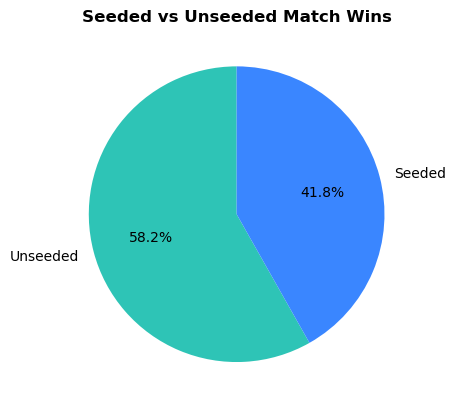

In [3]:
import matplotlib.pyplot as plt
# ---- Create Seeded vs Unseeded Wins ----
seeded_wins = matches_copy["winner_seed"].notna().value_counts()
seeded_wins.index = ["Seeded", "Unseeded"]
colors = ["#2EC4B6", "#3A86FF"]   # Teal & Blue combo

seeded_wins.plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Unseeded", "Seeded"],
    colors=colors,
    startangle=90
)

plt.title("Seeded vs Unseeded Match Wins", fontweight="bold")
plt.ylabel("")
plt.show()


Performance Analysis: Top Winning Unseeded Players

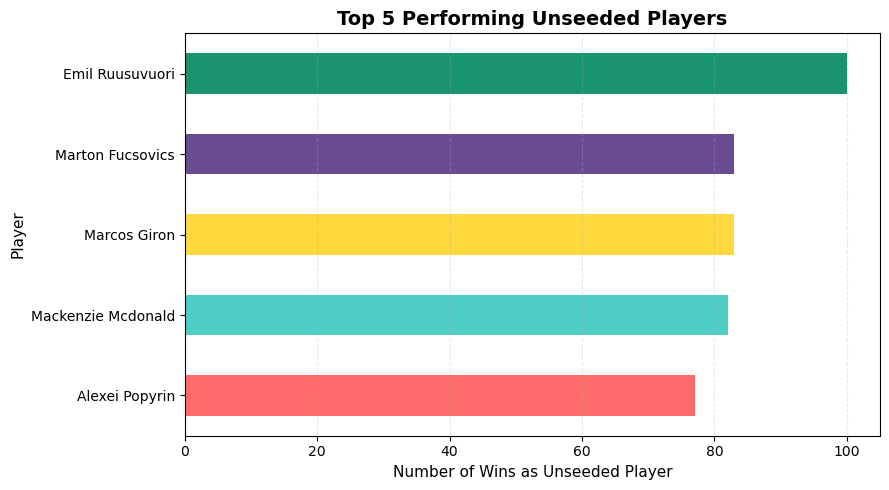

In [4]:
plt.figure(figsize=(9,5))

# gradient colors for bars
colors = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#6A4C93", "#1A936F"]

ax = top_unseeded_players.sort_values().plot(
    kind="barh",
    color=colors
)

# Title and labels
plt.title("Top 5 Performing Unseeded Players",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Wins as Unseeded Player", fontsize=11)
plt.ylabel("Player", fontsize=11)

# grid style
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


Ranking Distribution: Seeded vs Unseeded Players

Players are grouped into ranking tiers:
- Top 10
- Top 11–50
- Top 51–100
- 100+

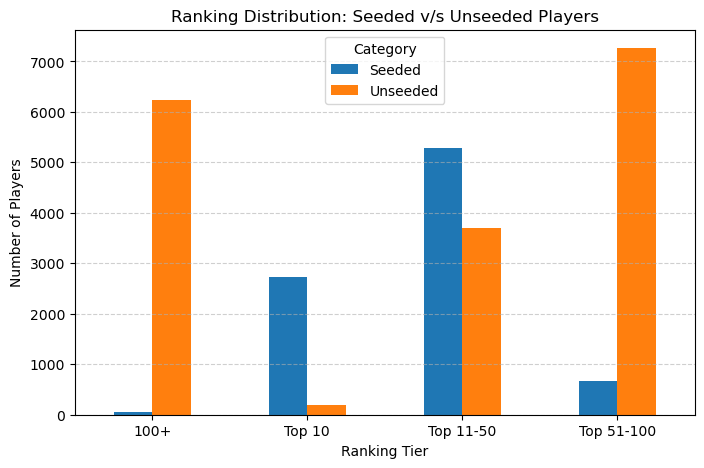

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy dataset
df = matches_copy.copy()

# Create Player Ranking Dataset

winner_df = df[["winner_seed", "winner_rank"]].copy()
winner_df.columns = ["seed", "rank"]

loser_df = df[["loser_seed", "loser_rank"]].copy()
loser_df.columns = ["seed", "rank"]

players_df = pd.concat([winner_df, loser_df])

# Remove missing rankings
players_df = players_df.dropna(subset=["rank"])


# Label Seeded vs Unseeded


players_df["Category"] = players_df["seed"].apply(
    lambda x: "Seeded" if pd.notna(x) else "Unseeded"
)


# Create Ranking Clusters

def ranking_cluster(rank):
    if rank <= 10:
        return "Top 10"
    elif rank <= 50:
        return "Top 11-50"
    elif rank <= 100:
        return "Top 51-100"
    else:
        return "100+"

players_df["Rank Cluster"] = players_df["rank"].apply(ranking_cluster)


# Create Cluster Table


cluster_table = pd.crosstab(players_df["Rank Cluster"], players_df["Category"])


# Plot Cluster Graph

cluster_table.plot(kind="bar", figsize=(8,5))

plt.title("Ranking Distribution: Seeded v/s Unseeded Players")
plt.xlabel("Ranking Tier")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()
